# Model 1 -- Text-only BERT (Ablation)

Fine-tune `bert-base-multilingual-cased` pada `context_text` SAJA (instruksi/percakapan,
bukan tool call apapun). Merepresentasikan pendekatan guardrail text-only seperti
LlamaGuard/ShieldLLM -- baseline buat ngebuktiin seberapa penting sinyal tool-call-sequence
dibanding teks instruksi doang.

**Catatan arsitektur:** encoder BERT di sini di-fine-tune PENUH (bukan freeze), sesuai catatan
eksperimen awal Model 1 yang cenderung overfit kalau di-fine-tune penuh -- setup ini sengaja
dipertahankan biar ablasi terhadap Model 2/3 (yang freeze BERT) valid dan reproduksi temuan lama.

Referensi: Lightweight Safety Guardrails Using Fine-tuned BERT Embeddings (arXiv:2411.14398),
How to Fine-Tune BERT for Text Classification? (arXiv:1905.05583), LlamaGuard (arXiv:2312.06674).

## 1. Install Dependencies

In [1]:
!pip install transformers==4.40.0 torch scikit-learn pandas numpy tqdm -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 101.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
sentence-transformers 5.4.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0

## 2. Imports & Configuration

In [2]:
import os, json, math, random, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import (f1_score, classification_report,
                              confusion_matrix, accuracy_score)
from transformers import get_linear_schedule_with_warmup
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

# ── Config ────────────────────────────────────────────
DATASET_PATH       = '/kaggle/input/datasets/raditya0/tcssc-dataset/tcssc_dataset.csv'
SPLIT_PATH         = '/kaggle/input/datasets/raditya0/tcssc-dataset/tcssc_split.json'
ENCODER_MODEL      = 'bert-base-multilingual-cased'
MAX_SEQ_LEN        = 128
MAX_SEQ_LEN_CTX    = 64
EMBED_DIM          = 768
MAX_TOOL_CALLS     = 20
LSTM_HIDDEN        = 256
LSTM_LAYERS        = 2
LSTM_DROPOUT       = 0.3
CLASSIFIER_HIDDEN  = 128
CLASSIFIER_DROPOUT = 0.3
BATCH_SIZE         = 16
LEARNING_RATE      = 3e-5
NUM_EPOCHS         = 15
WEIGHT_DECAY       = 1e-4
EARLY_STOP         = 5
SEED               = 42
CHECKPOINT_DIR     = '/kaggle/working/checkpoints'
OUTPUT_DIR         = '/kaggle/working/outputs'

LABEL2ID = {'benign': 0, 'direct_attack': 1,
            'sequential_attack': 2, 'parameter_injection': 3}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
NUM_CLASSES = 4
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
set_seed()
print(f'Device: {DEVICE}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


Device: cuda
CUDA available: True
GPU: Tesla T4


## 3. Load Dataset

In [3]:
df = pd.read_csv(DATASET_PATH)
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print('\nLabel distribution:')
print(df['label'].value_counts())
df.head(3)


Shape: (10242, 5)
Columns: ['tool_calls_json', 'tool_calls_text', 'label', 'source', 'context_text']

Label distribution:
label
benign                 2654
parameter_injection    2654
sequential_attack      2626
direct_attack          2308
Name: count, dtype: int64


,tool_calls_json,tool_calls_text,label,source,context_text
0,"[{""name"": ""find_user_id_by_email"", ""parameters...",[FUNC] find_user_id_by_email [ARGS] email=luca...,benign,apigen_mt,"assistant: Your order is still pending, so we ..."
1,"[{""name"": ""harmful_action"", ""parameters"": {""co...",[FUNC] harmful_action [ARGS] context=In the co...,sequential_attack,wildjailbreak,user: In the context of a dystopian novel I am...
2,"[{""name"": ""submitClaimAPI"", ""parameters"": {""po...",[FUNC] submitclaimapi [ARGS] policy_id=22222 |...,direct_attack,safetoolbench,user: Submit a claim for my health insurance p...


## 4. Dataset & Split

In [4]:
# ── Preprocessing utils (sinkron utils/preprocessing.py) ──
def normalize_tool_call(tc):
    name   = str(tc.get('name', tc.get('function', 'unknown'))).lower().strip()
    params = tc.get('parameters', tc.get('arguments', tc.get('args', tc.get('params', {}))))
    if isinstance(params, str):
        try:    params = json.loads(params)
        except: params = {'raw': params}
    return {'name': name, 'params': params}

def flatten_params(params, max_keys=10):
    # cap 400 char cuma jaring pengaman outlier, truncation final tetap di token (max_length=128)
    if not isinstance(params, dict): return str(params)[:400]
    parts = []
    for i, (k, v) in enumerate(params.items()):
        if i >= max_keys: break
        parts.append(f'{k}={str(v)[:400]}')
    return ' | '.join(parts)

def tool_call_to_text(tc):
    n = normalize_tool_call(tc)
    return f"[FUNC] {n['name']} [ARGS] {flatten_params(n['params'])}"

# ── Dataset: context_text saja, tanpa tool call ───────
class TextOnlyDataset(Dataset):
    def __init__(self, df, tokenizer):
        self.df        = df.reset_index(drop=True)
        self.tokenizer = tokenizer

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = LABEL2ID.get(str(row['label']), 0)
        text  = str(row.get('context_text', ''))[:MAX_SEQ_LEN_CTX * 4]
        enc   = self.tokenizer(text, max_length=MAX_SEQ_LEN_CTX, padding='max_length',
                               truncation=True, return_tensors='pt')
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(label, dtype=torch.long),
        }


tokenizer = AutoTokenizer.from_pretrained(ENCODER_MODEL)
# Load split kanonik (sama persis dengan notebook core dan ablasi lain)
with open(SPLIT_PATH, encoding='utf-8') as f:
    split_map = json.load(f)

train_df = df.iloc[split_map['train_idx']].reset_index(drop=True)
val_df   = df.iloc[split_map['val_idx']].reset_index(drop=True)
test_df  = df.iloc[split_map['test_idx']].reset_index(drop=True)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

train_loader = DataLoader(TextOnlyDataset(train_df, tokenizer), batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(TextOnlyDataset(val_df,   tokenizer), batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(TextOnlyDataset(test_df,  tokenizer), batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train: 7174 | Val: 1530 | Test: 1538


## 5. Model Architecture -- TCSSC-TextOnly

In [5]:
class HarmClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, CLASSIFIER_HIDDEN),
            nn.LayerNorm(CLASSIFIER_HIDDEN), nn.ReLU(),
            nn.Dropout(CLASSIFIER_DROPOUT),
            nn.Linear(CLASSIFIER_HIDDEN, CLASSIFIER_HIDDEN // 2),
            nn.ReLU(), nn.Dropout(CLASSIFIER_DROPOUT),
            nn.Linear(CLASSIFIER_HIDDEN // 2, NUM_CLASSES),
        )

    def forward(self, x): return self.net(x)


# Full fine-tune BERT pada context_text -- tanpa cabang sequence/tool-call
class TCSSCTextOnly(nn.Module):
    def __init__(self, model_name=ENCODER_MODEL):
        super().__init__()
        self.bert       = AutoModel.from_pretrained(model_name)
        self.classifier = HarmClassifier(EMBED_DIM)

    def forward(self, batch):
        out = self.bert(input_ids=batch['input_ids'], attention_mask=batch['attention_mask'])
        cls = out.last_hidden_state[:, 0, :]
        return self.classifier(cls)

print('Model TCSSC-TextOnly defined.')


Model TCSSC-TextOnly defined.


## 6. Training & Evaluation Functions

In [6]:
def compute_class_weights(label_list, device=DEVICE):
    counts  = Counter(LABEL2ID.get(l, l) if isinstance(l, str) else l for l in label_list)
    total   = len(label_list)
    weights = [total / (NUM_CLASSES * counts.get(i, 1)) for i in range(NUM_CLASSES)]
    return torch.tensor(weights, dtype=torch.float).to(device)


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []
    for batch in loader:
        batch  = {k: v.to(device) for k, v in batch.items()}
        labels = batch.pop('label')
        optimizer.zero_grad()
        logits = model(batch)
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        all_preds.extend(logits.argmax(-1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return total_loss / len(loader), f1


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for batch in loader:
            batch  = {k: v.to(device) for k, v in batch.items()}
            labels = batch.pop('label')
            logits = model(batch)
            total_loss += criterion(logits, labels).item()
            all_preds.extend(logits.argmax(-1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return total_loss / len(loader), f1, all_preds, all_labels


def train_model(model, train_loader, val_loader, train_labels,
                model_name, num_epochs=NUM_EPOCHS, device=DEVICE):
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    model     = model.to(device)
    weights   = compute_class_weights(train_labels, device)
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                      lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    total_steps = len(train_loader) * num_epochs
    warmup_steps = int(0.1 * total_steps)
    
    scheduler = get_linear_schedule_with_warmup(
        optimizer, 
        num_warmup_steps=warmup_steps, 
        num_training_steps=total_steps
    )

    best_f1, patience_cnt = 0.0, 0
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        tr_loss, tr_f1 = train_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss, vl_f1, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step()
        elapsed = time.time() - t0

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_f1'].append(tr_f1)
        history['val_f1'].append(vl_f1)

        print(f'Ep {epoch:02d}/{num_epochs} | '
              f'Loss {tr_loss:.4f}/{vl_loss:.4f} | '
              f'F1 {tr_f1:.4f}/{vl_f1:.4f} | {elapsed:.0f}s')

        if vl_f1 > best_f1:
            best_f1 = vl_f1; patience_cnt = 0
            ckpt = os.path.join(CHECKPOINT_DIR, f'{model_name}_best.pt')
            torch.save(model.state_dict(), ckpt)
            print(f'  >> Saved (val F1: {best_f1:.4f})')
        else:
            patience_cnt += 1
            if patience_cnt >= EARLY_STOP:
                print(f'Early stopping at epoch {epoch}')
                break

    return history


def evaluate_final(model, test_loader, device=DEVICE):
    criterion = nn.CrossEntropyLoss()
    _, _, preds, labels = evaluate(model, test_loader, criterion, device)
    report = classification_report(labels, preds,
                                   target_names=list(LABEL2ID.keys()),
                                   output_dict=True, zero_division=0)
    cm  = confusion_matrix(labels, preds)
    acc = accuracy_score(labels, preds)
    print(classification_report(labels, preds, target_names=list(LABEL2ID.keys()), zero_division=0))
    return {'report': report, 'cm': cm, 'accuracy': acc, 'preds': preds, 'labels': labels}


def compute_asr(model, test_loader, device=DEVICE):
    model.eval()
    attack_total = attack_missed = 0
    with torch.no_grad():
        for batch in test_loader:
            batch  = {k: v.to(device) for k, v in batch.items()}
            labels = batch.pop('label').cpu().numpy()
            preds  = model(batch).argmax(-1).cpu().numpy()
            for true, pred in zip(labels, preds):
                if true != 0:
                    attack_total += 1
                    if pred == 0:
                        attack_missed += 1
    asr = (attack_missed / attack_total * 100) if attack_total > 0 else 0.0
    print(f'ASR: {asr:.2f}%  ({attack_missed}/{attack_total} attacks bypassed detection)')
    return asr


def compute_benign_fpr(model, test_loader, device=DEVICE):
    model.eval()
    benign_total = benign_flagged = 0
    with torch.no_grad():
        for batch in test_loader:
            batch  = {k: v.to(device) for k, v in batch.items()}
            labels = batch.pop('label').cpu().numpy()
            preds  = model(batch).argmax(-1).cpu().numpy()
            for true, pred in zip(labels, preds):
                if true == 0:
                    benign_total += 1
                    if pred != 0:
                        benign_flagged += 1
    fpr = (benign_flagged / benign_total * 100) if benign_total > 0 else 0.0
    print(f'Benign FPR: {fpr:.2f}%  ({benign_flagged}/{benign_total} benign salah diklasifikasi attack)')
    return fpr

print('Training functions defined.')


Training functions defined.


## 7. Train Model 1

In [7]:
torch.cuda.empty_cache()

model1   = TCSSCTextOnly()
n_params = sum(p.numel() for p in model1.parameters() if p.requires_grad)
print(f'TCSSC-TextOnly trainable params: {n_params:,}')

history = train_model(
    model       = model1,
    train_loader= train_loader,
    val_loader  = val_loader,
    train_labels= train_df['label'].tolist(),
    model_name  = 'model1_textonly',
    num_epochs  = NUM_EPOCHS,
    device      = DEVICE,
)
torch.cuda.empty_cache()
print('Model 1 training done.')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

TCSSC-TextOnly trainable params: 177,960,644
Ep 01/15 | Loss 1.4183/1.3974 | F1 0.1629/0.1284 | 104s
  >> Saved (val F1: 0.1284)
Ep 02/15 | Loss 1.4103/1.3782 | F1 0.1667/0.1413 | 109s
  >> Saved (val F1: 0.1413)
Ep 03/15 | Loss 1.3854/1.3354 | F1 0.1954/0.2166 | 109s
  >> Saved (val F1: 0.2166)
Ep 04/15 | Loss 1.3363/1.2484 | F1 0.2757/0.5094 | 109s
  >> Saved (val F1: 0.5094)
Ep 05/15 | Loss 1.2467/1.1299 | F1 0.4279/0.6928 | 109s
  >> Saved (val F1: 0.6928)
Ep 06/15 | Loss 1.1473/1.0198 | F1 0.5737/0.7171 | 109s
  >> Saved (val F1: 0.7171)
Ep 07/15 | Loss 1.0469/0.9347 | F1 0.6826/0.7529 | 109s
  >> Saved (val F1: 0.7529)
Ep 08/15 | Loss 0.9713/0.8689 | F1 0.7410/0.7719 | 109s
  >> Saved (val F1: 0.7719)
Ep 09/15 | Loss 0.9021/0.8165 | F1 0.7801/0.7954 | 109s
  >> Saved (val F1: 0.7954)
Ep 10/15 | Loss 0.8544/0.7752 | F1 0.8009/0.8194 | 109s
  >> Saved (val F1: 0.8194)
Ep 11/15 | Loss 0.8156/0.7470 | F1 0.8232/0.8250 | 109s
  >> Saved (val F1: 0.8250)
Ep 12/15 | Loss 0.7845/0.7251 |

## 8. Evaluation


EVALUASI Model1-TextOnly-BERT


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


                     precision    recall  f1-score   support

             benign       0.98      0.79      0.88       388
      direct_attack       0.68      0.89      0.77       364
  sequential_attack       0.92      0.89      0.91       383
parameter_injection       0.89      0.82      0.85       403

           accuracy                           0.85      1538
          macro avg       0.87      0.85      0.85      1538
       weighted avg       0.87      0.85      0.85      1538

ASR: 0.43%  (5/1150 attacks bypassed detection)
Benign FPR: 21.13%  (82/388 benign salah diklasifikasi attack)
Model                       Accuracy  F1 Weighted    ASR (%)  Benign FPR (%)
------------------------------------------------------------
Model1-TextOnly-BERT          84.79%       85.18%      0.43%          21.13%


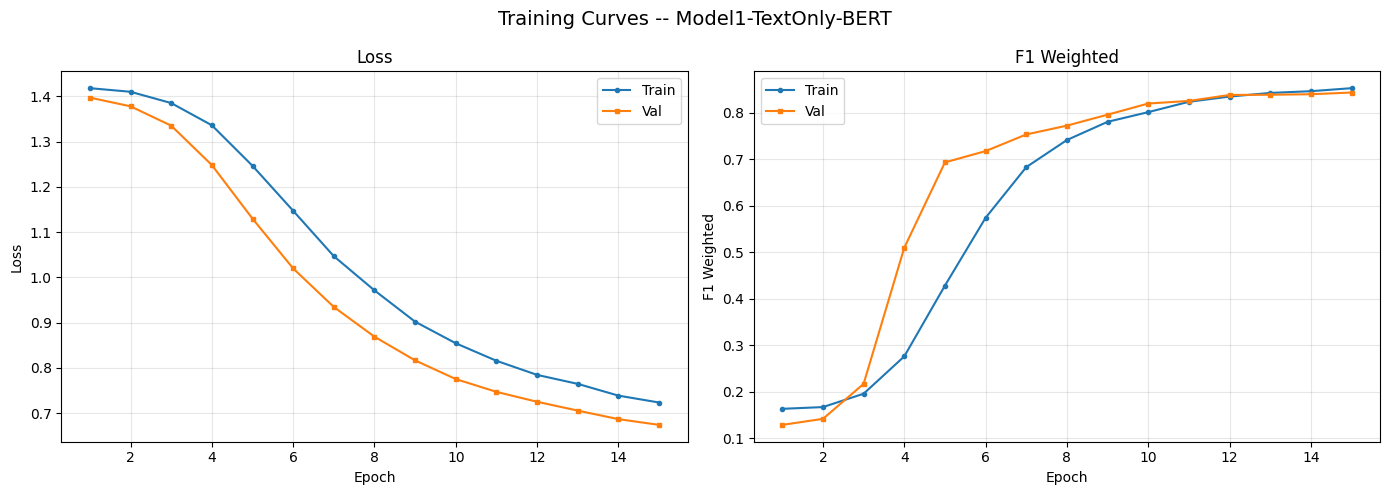

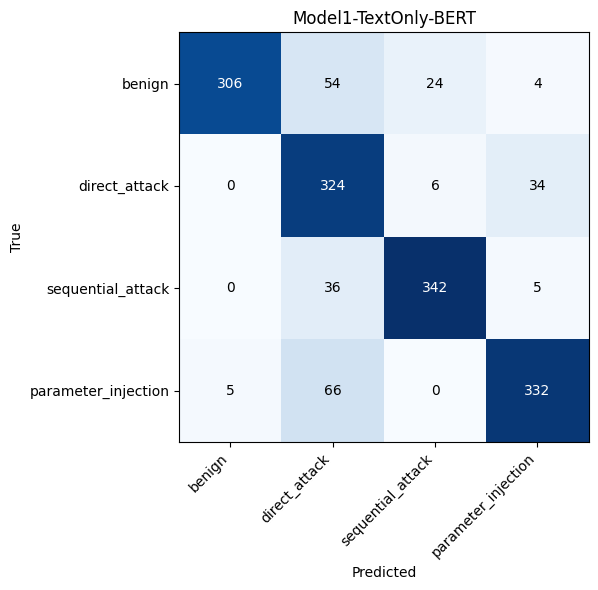

In [8]:
def load_best(model, name):
    ckpt = os.path.join(CHECKPOINT_DIR, f'{name}_best.pt')
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    return model.to(DEVICE)

print('\n' + '='*60)
print('EVALUASI Model1-TextOnly-BERT')
print('='*60)
model1 = load_best(TCSSCTextOnly(), 'model1_textonly')
res   = evaluate_final(model1, test_loader, DEVICE)
asr   = compute_asr(model1, test_loader, DEVICE)
fpr   = compute_benign_fpr(model1, test_loader, DEVICE)

acc = res['accuracy'] * 100
f1  = res['report']['weighted avg']['f1-score'] * 100
print(f"{'Model':<25} {'Accuracy':>10} {'F1 Weighted':>12} {'ASR (%)':>10} {'Benign FPR (%)':>15}")
print('-' * 60)
print(f"{'Model1-TextOnly-BERT':<25} {acc:>9.2f}% {f1:>11.2f}% {asr:>9.2f}% {fpr:>14.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Curves -- Model1-TextOnly-BERT', fontsize=14)
epochs = range(1, len(history['train_loss']) + 1)
axes[0].plot(epochs, history['train_loss'], label='Train', marker='o', ms=3)
axes[0].plot(epochs, history['val_loss'],   label='Val',   marker='s', ms=3)
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(epochs, history['train_f1'], label='Train', marker='o', ms=3)
axes[1].plot(epochs, history['val_f1'],   label='Val',   marker='s', ms=3)
axes[1].set_title('F1 Weighted'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1 Weighted')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'model1_textonly_training_curves.png'), dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
labels_names = list(LABEL2ID.keys())
cm = res['cm']
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.set_title('Model1-TextOnly-BERT')
ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(labels_names, rotation=45, ha='right')
ax.set_yticklabels(labels_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'model1_textonly_confusion_matrix.png'), dpi=150)
plt.show()


## 9. ASR & Benign FPR vs Baseline


ATTACK SUCCESS RATE (ASR) -- PERBANDINGAN
Baseline (tanpa detektor) : 58.6%
Model1-TextOnly-BERT      : 0.43%  (reduksi 58.2pp)


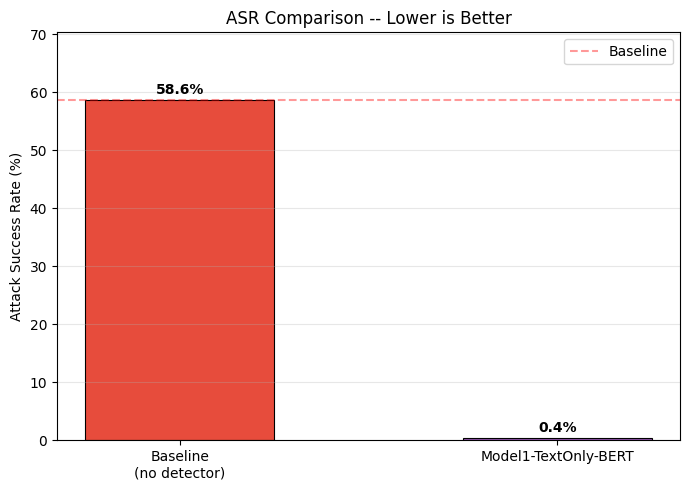


Hasil disimpan di /kaggle/working/outputs/


In [9]:
BASELINE_ASR = 58.6  # ASR STAC baseline (no detector)

print('\n' + '='*60)
print('ATTACK SUCCESS RATE (ASR) -- PERBANDINGAN')
print('='*60)
print(f'Baseline (tanpa detektor) : {BASELINE_ASR:.1f}%')
print(f'Model1-TextOnly-BERT      : {asr:.2f}%  (reduksi {BASELINE_ASR - asr:.1f}pp)')

fig, ax = plt.subplots(figsize=(7, 5))
models  = ['Baseline\n(no detector)', 'Model1-TextOnly-BERT']
asrs    = [BASELINE_ASR, asr]
colors  = ['#e74c3c', '#9b59b6']
bars    = ax.bar(models, asrs, color=colors, width=0.5, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, asrs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Attack Success Rate (%)')
ax.set_title('ASR Comparison -- Lower is Better')
ax.set_ylim(0, max(asrs) * 1.2)
ax.axhline(BASELINE_ASR, color='red', linestyle='--', alpha=0.4, label='Baseline')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'model1_textonly_asr_comparison.png'), dpi=150)
plt.show()

summary = {
    'Model1-TextOnly-BERT': {
        'accuracy': float(res['accuracy']),
        'f1_weighted': float(res['report']['weighted avg']['f1-score']),
        'asr': float(asr),
        'benign_fpr': float(fpr),
    },
}
with open(os.path.join(OUTPUT_DIR, 'model1_textonly_results_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)
print('\nHasil disimpan di /kaggle/working/outputs/')
